## **Fase 3 - Modelado, validación temporal y calibración**

Esta fase responde la pregunta de investigación del proyecto: aporta el machine
learning una mejora real sobre los modelos estadísticos clásicos en la predicción
de resultados de fútbol internacional. Para responderla se construyen, validan y
comparan cuatro modelos sobre la matriz `data_features.csv` de la Fase 2:

1. Baseline trivial - predicción por ranking FIFA. Es el piso de comparación.
2. Poisson independiente (Maher, 1982) - modelo estadístico clásico, núcleo.
3. Dixon-Coles (1997) - extensión del Poisson con corrección de marcadores bajos
   y ponderación temporal. Es el objetivo opcional de la metodología.
4. XGBoost multinomial - modelo de aprendizaje automático, núcleo.

La validación es temporal sobre los Mundiales 2010, 2014, 2018 y 2022. Las
métricas principales son log-loss y Brier score (calidad de las probabilidades);
accuracy es secundaria. Todo se compara contra el baseline. Se analiza además la
calibración de cada modelo, no solo su discriminación.

---
## 1. Imports y configuración

Semilla global 42 en numpy y en XGBoost. El pipeline de modelado es determinista.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import poisson
from scipy.optimize import minimize
from sklearn.metrics import log_loss, accuracy_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 170)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (9, 4.5)

RAW_DIR  = Path("datos")       # datos fuente
OUT_DIR  = Path("resultados")  # CSVs generados entre fases
FIGS_DIR = Path("figuras")     # figuras para LaTeX
OUT_DIR.mkdir(exist_ok=True); FIGS_DIR.mkdir(exist_ok=True)

print("Entorno listo. Semilla =", SEED)

Entorno listo. Semilla = 42


---
## 2. Carga de datos y definición del problema

Se carga `data_features.csv` (salida de la Fase 2). La variable objetivo es el
resultado del partido en tres clases, codificado como 0 = victoria local (H),
1 = empate (D), 2 = victoria visitante (A). Este orden se mantiene fijo en todo
el notebook para que las columnas de probabilidad sean siempre comparables.

Nota sobre los partidos de eliminatoria. En `results.csv` un partido de fase
final que se decidió por penales figura con el marcador de los 90 o 120 minutos,
es decir, como empate. El modelo predice el resultado reglamentario en tres
clases, no el ganador de la tanda, de modo que tratar esos partidos como empate
es coherente con lo que el modelo estima. El ganador real por penales quedó
guardado en `winner_by_shootout` (Fase 1) y se reserva para la simulación.

In [2]:
data = pd.read_csv(OUT_DIR / "data_features.csv", parse_dates=["date"])

CLASES = ["H", "D", "A"]
COD = {"H": 0, "D": 1, "A": 2}
data["y"] = data["outcome"].map(COD)

print(f"Partidos en la matriz: {len(data):,}")
print(f"Rango temporal       : {data['date'].min().date()} -> {data['date'].max().date()}")
print("Distribución de la variable objetivo (toda la ventana):")
print((data["outcome"].value_counts(normalize=True) * 100).round(1).astype(str) + " %")

Partidos en la matriz: 23,086
Rango temporal       : 2002-01-04 -> 2026-03-31
Distribución de la variable objetivo (toda la ventana):
outcome
H    47.9 %
A    28.8 %
D    23.3 %
Name: proportion, dtype: object


---
## 3. Esquema de validación temporal

Principio rector, no negociable: la validación es temporal, nunca aleatoria.
Mezclar partidos posteriores en el entrenamiento produce fuga de datos y
sobreestima el desempeño.

Se usa una ventana expansiva con cuatro pliegues. Para cada Mundial, el modelo se
entrena con todos los partidos anteriores a su primer encuentro y se valida sobre
los 64 partidos de ese Mundial:

| Pliegue | Entrenamiento | Validación |
|---|---|---|
| 1 | partidos hasta junio 2010 | Mundial 2010 |
| 2 | partidos hasta junio 2014 | Mundial 2014 |
| 3 | partidos hasta junio 2018 | Mundial 2018 |
| 4 | partidos hasta noviembre 2022 | Mundial 2022 |

Las métricas se promedian sobre los cuatro pliegues. Se reporta también la
desviación entre pliegues como indicador de estabilidad; con solo cuatro pliegues
es una estimación gruesa, pero informa sobre la consistencia del modelo.

Consideración sobre el conjunto de validación. Cada Mundial aporta 64 partidos
entre selecciones de élite, de paridad alta. Es un conjunto pequeño y difícil,
deliberadamente: es el escenario donde el proyecto quiere medir el desempeño. La
contrapartida es que las diferencias entre modelos serán de magnitud modesta y la
varianza entre pliegues, apreciable. Ambas cosas se interpretan en la sección 10.

In [3]:
FOLDS = [2010, 2014, 2018, 2022]

def particion(anio):
    '''Devuelve (train, valid) para el pliegue del Mundial indicado.'''
    wc = data[(data["tournament"] == "FIFA World Cup")
              & (data["date"].dt.year == anio)]
    inicio = wc["date"].min()
    train = data[data["date"] < inicio].copy()
    valid = wc.copy()
    return train, valid, inicio

print("Tamaño de cada pliegue:")
for a in FOLDS:
    tr, va, ini = particion(a)
    print(f"  Mundial {a}: entrena {len(tr):>6,} | valida {len(va)} "
          f"(corte {ini.date()})")

Tamaño de cada pliegue:
  Mundial 2010: entrena  7,729 | valida 64 (corte 2010-06-11)
  Mundial 2014: entrena 11,698 | valida 64 (corte 2014-06-12)
  Mundial 2018: entrena 15,476 | valida 64 (corte 2018-06-14)
  Mundial 2022: entrena 19,534 | valida 64 (corte 2022-11-20)


---
## 4. Métricas de evaluación

Tres métricas, todas sobre la predicción probabilística de tres clases:

- Log-loss (entropía cruzada). Métrica principal. Penaliza con dureza la
  confianza mal puesta. Referencia: una predicción uniforme (1/3, 1/3, 1/3) da
  log(3) = 1.0986; todo modelo útil debe quedar por debajo.
- Brier score multiclase. Métrica principal. Es el error cuadrático medio entre
  el vector de probabilidad y el resultado real en codificación one-hot
  (Brier, 1950). Rango de 0 a 2; menor es mejor.
- Accuracy. Métrica secundaria, de referencia. Solo mira el acierto de la clase
  más probable e ignora la calidad de la probabilidad.

Tanto log-loss como Brier son reglas de puntuación estrictamente propias
(Gneiting y Raftery, 2007): se optimizan únicamente prediciendo la probabilidad
verdadera, lo que las hace adecuadas para un proyecto cuyo fin es alimentar
quinielas.

In [4]:
def brier_multiclase(y, P):
    '''Brier score multiclase: EMC entre P y el resultado real en one-hot.'''
    oh = np.zeros_like(P, dtype=float)
    oh[np.arange(len(y)), y] = 1.0
    return np.mean(((P - oh) ** 2).sum(axis=1))

def evaluar(y, P):
    '''Devuelve las tres métricas para una matriz de probabilidades P (n x 3).'''
    return {
        "logloss": log_loss(y, P, labels=[0, 1, 2]),
        "brier": brier_multiclase(y, P),
        "accuracy": accuracy_score(y, P.argmax(axis=1)),
    }

---
## 5. Modelo 1 - Baseline trivial

El baseline formaliza la heurística más simple: gana el equipo con mejor ranking
FIFA. Para que sea evaluable con log-loss necesita emitir probabilidades, no solo
una clase, así que se calibra con dos cantidades estimadas en el entrenamiento:

- d = frecuencia histórica de empate.
- w = probabilidad de que el equipo mejor clasificado gane, condicionada a que el
  partido no termine en empate.

Para cada partido, si el local tiene mejor ranking se asigna P(H) = (1-d)*w,
P(A) = (1-d)*(1-w) y P(D) = d; si el mejor clasificado es el visitante, se
intercambian H y A. Cuando falta el ranking de algún equipo (territorios no FIFA,
sección 8 de la Fase 1) se reparte 1-d en partes iguales entre H y A.

Este baseline no es un hombre de paja: usa el ranking FIFA, que es un predictor
informativo, y emite probabilidades calibradas con frecuencias reales. Superarlo
de forma clara es una exigencia genuina para los modelos más complejos.

In [5]:
def baseline_fit(train):
    d = (train["outcome"] == "D").mean()
    no_emp = train[train["outcome"] != "D"].dropna(
        subset=["home_fifa_rank", "away_fifa_rank"])
    local_mejor = no_emp["home_fifa_rank"] < no_emp["away_fifa_rank"]
    gana_mejor = ((local_mejor & (no_emp["outcome"] == "H"))
                  | (~local_mejor & (no_emp["outcome"] == "A"))).mean()
    return {"d": d, "w": gana_mejor}

def baseline_predict(par, df):
    d, w = par["d"], par["w"]
    P = np.zeros((len(df), 3))
    for i, r in enumerate(df.itertuples(index=False)):
        hr, ar = r.home_fifa_rank, r.away_fifa_rank
        if pd.isna(hr) or pd.isna(ar) or hr == ar:
            P[i] = [(1 - d) / 2, d, (1 - d) / 2]
        elif hr < ar:                       # menor rank = mejor equipo
            P[i] = [(1 - d) * w, d, (1 - d) * (1 - w)]
        else:
            P[i] = [(1 - d) * (1 - w), d, (1 - d) * w]
    return P

# Vistazo a los parametros estimados en el pliegue mas largo.
par_demo = baseline_fit(particion(2022)[0])
print(f"Baseline (entrenado hasta 2022): P(empate) = {par_demo['d']:.3f}, "
      f"P(gana el mejor | no empate) = {par_demo['w']:.3f}")

Baseline (entrenado hasta 2022): P(empate) = 0.234, P(gana el mejor | no empate) = 0.723


---
## 6. Modelo 2 - Poisson independiente (Maher, 1982)

### 6.1 Formulación

Los goles de cada equipo se modelan como variables Poisson independientes. En
escala logarítmica:

    log(lambda_local)     = c + ataque_local  + defensa_visitante + gamma
    log(lambda_visitante) = c + ataque_local' + defensa_local

donde cada selección tiene un parámetro de ataque y uno de defensa, gamma es la
ventaja de local (se anula en cancha neutral) y c es un intercepto común. Los
parámetros se estiman por máxima verosimilitud. La estimación se plantea como un
modelo lineal generalizado de Poisson: el conjunto de partidos se reorganiza a
formato largo (dos filas por partido, una por cada equipo anotador) y se ajusta
con `statsmodels`. De la distribución conjunta de marcadores, construida como el
producto exterior de las dos marginales Poisson, se obtienen las probabilidades
de victoria local, empate y victoria visitante.

### 6.2 Decisión: agrupación de equipos con poco historial

El riesgo de equipos con poco historial (declarado en el Marco Metodológico) se
manifiesta aquí de forma directa: una selección con dos o tres partidos en la
ventana recibe estimaciones de ataque y defensa inestables, a veces extremas. Sin
control, un equipo marginal podía aparecer con el mayor ataque de toda la tabla.

Decisión aplicada: las selecciones con menos de `MIN_MATCHES` = 10 partidos en la
ventana de entrenamiento se agrupan en una única categoría `Other`. Esto estabiliza
la estimación sin perder información relevante, porque ningún equipo agrupado
disputa el Mundial. En predicción, un equipo no visto o agrupado se mapea a `Other`.
Es una decisión documentada; subir o bajar el umbral es trivial.

Nota de implementación sobre el signo. El GLM entrega un coeficiente por equipo
como defensor. Un buen defensor recibe pocos goles, de modo que ese coeficiente
es negativo. Para la formulación de Maher se mantiene tal cual: lo que importa es
la suma en la escala logarítmica, no el nombre del término. Tras el ajuste, los
parámetros de ataque y de defensa se centran en su media y la media se absorbe en
el intercepto, de manera que el valor 0 representa a un equipo promedio.

In [6]:
MIN_MATCHES = 10   # umbral de agrupación de equipos con poco historial

def a_formato_largo(df):
    '''Dos filas por partido: una por cada equipo en rol de anotador.'''
    loc = pd.DataFrame({"goals": df["home_score"].values,
                        "attacker": df["home_team"].values,
                        "defender": df["away_team"].values, "is_home": 1})
    vis = pd.DataFrame({"goals": df["away_score"].values,
                        "attacker": df["away_team"].values,
                        "defender": df["home_team"].values, "is_home": 0})
    return pd.concat([loc, vis], ignore_index=True)

def agrupar_raros(train):
    '''Devuelve (train con equipos raros como 'Other', conjunto de raros).'''
    cnt = pd.concat([train["home_team"], train["away_team"]]).value_counts()
    raros = set(cnt[cnt < MIN_MATCHES].index)
    tr = train.copy()
    for col in ("home_team", "away_team"):
        tr[col] = tr[col].where(~tr[col].isin(raros), "Other")
    return tr, raros

def poisson_fit(train):
    tr, raros = agrupar_raros(train)
    modelo = smf.glm("goals ~ is_home + C(attacker) + C(defender)",
                     data=a_formato_largo(tr),
                     family=sm.families.Poisson()).fit()
    p = modelo.params
    equipos = sorted(set(tr["home_team"]) | set(tr["away_team"]))
    atk = {t: 0.0 for t in equipos}
    dfn = {t: 0.0 for t in equipos}
    for nombre, valor in p.items():
        if nombre.startswith("C(attacker)[T."):
            atk[nombre[14:-1]] = valor
        elif nombre.startswith("C(defender)[T."):
            dfn[nombre[14:-1]] = valor
    ma = np.mean(list(atk.values()))
    md = np.mean(list(dfn.values()))
    atk = {t: atk[t] - ma for t in equipos}
    dfn = {t: dfn[t] - md for t in equipos}
    return {"intercept": p["Intercept"] + ma + md, "gamma": p["is_home"],
            "atk": atk, "dfn": dfn, "raros": raros}

def _equipo(par, t):
    '''Mapea un equipo a 'Other' si es raro o no fue visto en entrenamiento.'''
    return "Other" if (t in par["raros"] or t not in par["atk"]) else t

def poisson_predict(par, df, max_goles=10):
    P = np.zeros((len(df), 3))
    rango = np.arange(max_goles + 1)
    a, d = par["atk"], par["dfn"]
    for i, r in enumerate(df.itertuples(index=False)):
        h, aw = _equipo(par, r.home_team), _equipo(par, r.away_team)
        vis_local = 0.0 if r.neutral else par["gamma"]
        lam = np.exp(par["intercept"] + a.get(h, 0) + d.get(aw, 0) + vis_local)
        mu = np.exp(par["intercept"] + a.get(aw, 0) + d.get(h, 0))
        M = np.outer(poisson.pmf(rango, lam), poisson.pmf(rango, mu))
        M /= M.sum()
        P[i] = [np.tril(M, -1).sum(), np.trace(M), np.triu(M, 1).sum()]
    return P

### 6.3 Inspección del modelo ajustado

Antes de validar conviene confirmar que los parámetros tienen sentido futbolístico.
Se ajusta el Poisson sobre el pliegue más largo (entrenamiento hasta 2022) y se
revisan el intercepto, la ventaja de local y las tablas de ataque y defensa.

In [7]:
par_pois = poisson_fit(particion(2022)[0])
print(f"Intercepto c   : {par_pois['intercept']:.3f}  "
      f"(goles base por equipo: {np.exp(par_pois['intercept']):.2f})")
print(f"Ventaja local  : gamma = {par_pois['gamma']:.3f}  "
      f"(factor multiplicativo {np.exp(par_pois['gamma']):.2f}x sobre lambda)")

atk = pd.Series(par_pois["atk"]).drop("Other", errors="ignore")
dfn = pd.Series(par_pois["dfn"]).drop("Other", errors="ignore")
resumen = pd.DataFrame({
    "mejor ataque": atk.sort_values(ascending=False).head(8).round(2).index,
    "valor atk": atk.sort_values(ascending=False).head(8).round(2).values,
    "mejor defensa": dfn.sort_values().head(8).round(2).index,
    "valor def": dfn.sort_values().head(8).round(2).values,
})
display(resumen)

Intercepto c   : 0.071  (goles base por equipo: 1.07)
Ventaja local  : gamma = 0.309  (factor multiplicativo 1.36x sobre lambda)


,mejor ataque,valor atk,mejor defensa,valor def
0,Brazil,1.4000,Brazil,-1.5300
1,Germany,1.3500,Spain,-1.4100
2,Spain,1.2800,France,-1.3500
3,Argentina,1.2500,England,-1.2600
4,Netherlands,1.2000,Argentina,-1.2500
5,England,1.1700,Colombia,-1.2400
6,Catalonia,1.1400,Italy,-1.2200
7,Portugal,1.1300,Netherlands,-1.2100


---
## 7. Modelo 3 - Dixon-Coles (1997)

### 7.1 Qué añade sobre el Poisson

Dixon y Coles (1997) extienden el modelo de Maher con dos correcciones, ambas
pensadas para el pronóstico:

1. Dependencia en marcadores bajos. El Poisson independiente subestima de forma
   sistemática los resultados 0-0, 1-0, 0-1 y 1-1. Un parámetro rho corrige la
   probabilidad de esas cuatro celdas mediante un factor de ajuste tau. Si rho es
   negativo, el modelo incrementa la masa del 0-0 y del 1-1 y la reduce en el 1-0
   y el 0-1.
2. Ponderación temporal. Cada partido del entrenamiento recibe un peso que decae
   de forma exponencial con su antigüedad, de modo que el desempeño reciente pesa
   más. El decaimiento se controla con una vida media; aquí se fija en dos años
   (`HALF_LIFE_DIAS`). Es un valor razonable para el fútbol de selecciones, donde
   los equipos juegan con poca frecuencia; tratarlo como hiperparámetro a calibrar
   es una extensión posible.

### 7.2 Decisión: estimación por máxima verosimilitud con gradiente analítico

El modelo no se puede ajustar con un GLM estándar porque la verosimilitud es
ponderada e incluye el factor tau, que acopla ambos marcadores. Se implementa la
log-verosimilitud ponderada de forma explícita y se optimiza con L-BFGS-B.

Decisión relevante: se deriva y se programa el gradiente analítico de la
log-verosimilitud, en lugar de dejar que el optimizador lo aproxime por
diferencias finitas. Con más de 400 parámetros, el gradiente numérico es lento y
ruidoso, y en pruebas no alcanzaba la convergencia. El gradiente analítico
resuelve ambos problemas: el ajuste converge en cerca de un segundo por pliegue.
La corrección del gradiente se verifica en la sección 7.4 con `check_grad`.

La identificabilidad se gestiona fijando el ataque y la defensa del primer equipo
en cero durante la optimización; al terminar, los parámetros se centran en su
media igual que en el Poisson, de modo que 0 vuelve a representar a un equipo
promedio. La agrupación de equipos con poco historial es la misma del Poisson.

In [8]:
HALF_LIFE_DIAS = 730   # vida media de la ponderación temporal (2 años)

def _dc_preparar(train, ref_date):
    '''Construye los arreglos vectorizados que consumen la verosimilitud y el gradiente.'''
    tr, raros = agrupar_raros(train)
    equipos = sorted(set(tr["home_team"]) | set(tr["away_team"]))
    n = len(equipos)
    idx = {t: i for i, t in enumerate(equipos)}
    A = {
        "n": n, "equipos": equipos, "idx": idx, "raros": raros,
        "hi": tr["home_team"].map(idx).values,
        "ai": tr["away_team"].map(idx).values,
        "x": tr["home_score"].values.astype(float),
        "y": tr["away_score"].values.astype(float),
        "home": (~tr["neutral"]).astype(float).values,
    }
    tasa = np.log(2) / HALF_LIFE_DIAS
    A["w"] = np.exp(-tasa * (ref_date - tr["date"]).dt.days.values)
    bajos = (A["x"] <= 1) & (A["y"] <= 1)
    A["m00"] = bajos & (A["x"] == 0) & (A["y"] == 0)
    A["m01"] = bajos & (A["x"] == 0) & (A["y"] == 1)
    A["m10"] = bajos & (A["x"] == 1) & (A["y"] == 0)
    A["m11"] = bajos & (A["x"] == 1) & (A["y"] == 1)
    return A

def _dc_unpack(p, n):
    atk = np.concatenate([[0.0], p[:n - 1]])
    dfn = np.concatenate([[0.0], p[n - 1:2 * n - 2]])
    return atk, dfn, p[2 * n - 2], p[2 * n - 1], p[2 * n]

def _dc_negll(p, A):
    n = A["n"]
    atk, dfn, c, g, rho = _dc_unpack(p, n)
    ll_lam = c + atk[A["hi"]] + dfn[A["ai"]] + g * A["home"]
    ll_mu = c + atk[A["ai"]] + dfn[A["hi"]]
    lam, mu = np.exp(ll_lam), np.exp(ll_mu)
    pois = A["x"] * ll_lam - lam + A["y"] * ll_mu - mu
    tau = np.ones(len(lam))
    tau[A["m00"]] = 1 - lam[A["m00"]] * mu[A["m00"]] * rho
    tau[A["m01"]] = 1 + lam[A["m01"]] * rho
    tau[A["m10"]] = 1 + mu[A["m10"]] * rho
    tau[A["m11"]] = 1 - rho
    if np.any(tau <= 1e-10):
        return 1e10
    return -np.sum(A["w"] * (pois + np.log(tau)))

def _dc_grad(p, A):
    n = A["n"]
    atk, dfn, c, g, rho = _dc_unpack(p, n)
    hi, ai, home, w = A["hi"], A["ai"], A["home"], A["w"]
    ll_lam = c + atk[hi] + dfn[ai] + g * home
    ll_mu = c + atk[ai] + dfn[hi]
    lam, mu = np.exp(ll_lam), np.exp(ll_mu)
    g_lam = A["x"] - lam            # residuo Poisson
    g_mu = A["y"] - mu
    g_rho = np.zeros(len(lam))
    tau = np.ones(len(lam))
    tau[A["m00"]] = 1 - lam[A["m00"]] * mu[A["m00"]] * rho
    tau[A["m01"]] = 1 + lam[A["m01"]] * rho
    tau[A["m10"]] = 1 + mu[A["m10"]] * rho
    tau[A["m11"]] = 1 - rho
    d_lam = np.zeros(len(lam))
    d_mu = np.zeros(len(lam))
    lm = lam * mu
    d_lam[A["m00"]] += -lm[A["m00"]] * rho / tau[A["m00"]]
    d_mu[A["m00"]] += -lm[A["m00"]] * rho / tau[A["m00"]]
    g_rho[A["m00"]] += -lm[A["m00"]] / tau[A["m00"]]
    d_lam[A["m01"]] += lam[A["m01"]] * rho / tau[A["m01"]]
    g_rho[A["m01"]] += lam[A["m01"]] / tau[A["m01"]]
    d_mu[A["m10"]] += mu[A["m10"]] * rho / tau[A["m10"]]
    g_rho[A["m10"]] += mu[A["m10"]] / tau[A["m10"]]
    g_rho[A["m11"]] += -1.0 / tau[A["m11"]]
    g_lam = w * (g_lam + d_lam)
    g_mu = w * (g_mu + d_mu)
    g_atk = np.bincount(hi, g_lam, n) + np.bincount(ai, g_mu, n)
    g_dfn = np.bincount(ai, g_lam, n) + np.bincount(hi, g_mu, n)
    g_c = g_lam.sum() + g_mu.sum()
    g_g = (g_lam * home).sum()
    g_r = (w * g_rho).sum()
    grad = np.concatenate([g_atk[1:], g_dfn[1:], [g_c, g_g, g_r]])
    return -grad

def dc_fit(train, ref_date):
    A = _dc_preparar(train, ref_date)
    n = A["n"]
    p0 = np.zeros(2 * n + 1)
    p0[2 * n - 1] = 0.3
    limites = [(-3, 3)] * (2 * n - 2) + [(-2, 2), (-1, 1), (-0.2, 0.2)]
    res = minimize(_dc_negll, p0, jac=_dc_grad, args=(A,), method="L-BFGS-B",
                   bounds=limites, options={"maxiter": 5000, "ftol": 1e-10,
                                            "gtol": 1e-6})
    atk, dfn, c, g, rho = _dc_unpack(res.x, n)
    ma, md = atk.mean(), dfn.mean()
    return {"intercept": c + ma + md, "gamma": g, "rho": rho,
            "atk": {t: atk[i] - ma for t, i in A["idx"].items()},
            "dfn": {t: dfn[i] - md for t, i in A["idx"].items()},
            "raros": A["raros"], "converge": res.success, "iteraciones": res.nit}

def dc_predict(par, df, max_goles=10):
    P = np.zeros((len(df), 3))
    rango = np.arange(max_goles + 1)
    a, d, rho = par["atk"], par["dfn"], par["rho"]
    for i, r in enumerate(df.itertuples(index=False)):
        h, aw = _equipo(par, r.home_team), _equipo(par, r.away_team)
        vis_local = 0.0 if r.neutral else par["gamma"]
        lam = np.exp(par["intercept"] + a.get(h, 0) + d.get(aw, 0) + vis_local)
        mu = np.exp(par["intercept"] + a.get(aw, 0) + d.get(h, 0))
        M = np.outer(poisson.pmf(rango, lam), poisson.pmf(rango, mu))
        M[0, 0] *= 1 - lam * mu * rho
        M[0, 1] *= 1 + lam * rho
        M[1, 0] *= 1 + mu * rho
        M[1, 1] *= 1 - rho
        M = np.clip(M, 0, None)
        M /= M.sum()
        P[i] = [np.tril(M, -1).sum(), np.trace(M), np.triu(M, 1).sum()]
    return P

### 7.3 Inspección del modelo ajustado

In [9]:
_, _, corte_2022 = particion(2022)
par_dc = dc_fit(particion(2022)[0], corte_2022)
print(f"Convergencia   : {par_dc['converge']} en {par_dc['iteraciones']} iteraciones")
print(f"Intercepto c   : {par_dc['intercept']:.3f}")
print(f"Ventaja local  : gamma = {par_dc['gamma']:.3f}")
print(f"Corrección rho : {par_dc['rho']:.4f}  "
      f"({'positiva' if par_dc['rho'] > 0 else 'negativa'})")

Convergencia   : True en 1284 iteraciones
Intercepto c   : 0.081
Ventaja local  : gamma = 0.267
Corrección rho : -0.0259  (negativa)


### 7.4 Verificación del gradiente analítico

`check_grad` compara el gradiente analítico con una aproximación por diferencias
finitas en un punto aleatorio. Un error pequeño confirma que la derivada
programada es correcta, requisito para confiar en la convergencia del optimizador.

In [10]:
from scipy.optimize import check_grad

A_chk = _dc_preparar(particion(2010)[0], particion(2010)[2])
punto = np.random.RandomState(0).normal(0, 0.05, 2 * A_chk["n"] + 1)
error = check_grad(_dc_negll, _dc_grad, punto, A_chk)
print(f"check_grad - error entre gradiente analítico y numérico: {error:.2e}")
print("Un valor del orden de 1e-3 o menor confirma el gradiente.")

check_grad - error entre gradiente analítico y numérico: 8.11e-04
Un valor del orden de 1e-3 o menor confirma el gradiente.


---
## 8. Modelo 4 - XGBoost multinomial

### 8.1 Diseño

XGBoost (Chen y Guestrin, 2016) es un modelo de gradient boosting que predice de
forma directa la distribución sobre las tres clases a partir del vector de
features de la Fase 2. A diferencia del Poisson y de Dixon-Coles, no modela los
goles: aprende la relación entre las variables (Elo, ranking, forma reciente,
descanso, contexto) y el resultado, y capta interacciones no lineales que los
modelos de goles no representan.

Las variables categóricas de confederación se codifican one-hot. El resto de
features son numéricas y se pasan tal cual; los valores faltantes se dejan como
NaN, que XGBoost maneja de forma nativa aprendiendo la mejor dirección de
ramificación para el dato ausente.

### 8.2 Decisión: hiperparámetros fijos y conservadores

El sobreajuste es el riesgo principal de XGBoost (declarado en el Marco
Metodológico). Una búsqueda extensa de hiperparámetros, además, abre la puerta a
una fuga sutil: si se ajustan mirando el desempeño en los Mundiales de validación,
esas métricas dejan de ser una estimación honesta.

Decisión aplicada: se fijan hiperparámetros conservadores, sin búsqueda sobre los
pliegues de validación. Profundidad baja (`max_depth` = 4), tasa de aprendizaje
pequeña (0.05), submuestreo de filas y de columnas (0.8) y regularización
(`min_child_weight` = 5, `reg_lambda` = 1). El objetivo es un modelo robusto, no
uno afinado al límite. La alternativa rigurosa, una validación cruzada temporal
anidada para elegir los hiperparámetros dentro de cada entrenamiento, es la
extensión natural si se quisiera exprimir el desempeño; se deja documentada como
línea de trabajo futuro. Reportar el desempeño de un modelo deliberadamente no
afinado es la opción honesta y conservadora para responder la pregunta de
investigación.

In [11]:
# Variables numéricas de la Fase 2.
FEATURES_NUM = [
    "home_elo_pre", "away_elo_pre", "elo_diff", "elo_exp_home",
    "home_fifa_rank", "away_fifa_rank", "home_fifa_points", "away_fifa_points",
    "rank_diff", "points_diff",
    "home_gf_avg_5", "home_ga_avg_5", "home_pts_avg_5",
    "home_gf_avg_10", "home_ga_avg_10", "home_pts_avg_10",
    "away_gf_avg_5", "away_ga_avg_5", "away_pts_avg_5",
    "away_gf_avg_10", "away_ga_avg_10", "away_pts_avg_10",
    "pts_avg_diff_5", "pts_avg_diff_10",
    "home_rest_days", "away_rest_days", "rest_diff",
    "home_matches_prior", "away_matches_prior",
    "neutral", "is_official", "intercontinental",
]

# One-hot de confederación sobre toda la matriz (categorías fijas, sin fuga).
data_oh = pd.get_dummies(data, columns=["home_conf", "away_conf"], dummy_na=True)
COLS_CONF = [c for c in data_oh.columns
             if c.startswith(("home_conf_", "away_conf_"))]
FEATURES_XGB = FEATURES_NUM + COLS_CONF

HIPER_XGB = dict(objective="multi:softprob", num_class=3, max_depth=4,
                 learning_rate=0.05, n_estimators=300, subsample=0.8,
                 colsample_bytree=0.8, min_child_weight=5, reg_lambda=1.0,
                 random_state=SEED, n_jobs=-1, verbosity=0, eval_metric="mlogloss")

def xgb_fit(train_oh):
    modelo = XGBClassifier(**HIPER_XGB)
    modelo.fit(train_oh[FEATURES_XGB], train_oh["y"])
    return modelo

def xgb_predict(modelo, valid_oh):
    return modelo.predict_proba(valid_oh[FEATURES_XGB])

print(f"XGBoost - {len(FEATURES_XGB)} features "
      f"({len(FEATURES_NUM)} numéricas + {len(COLS_CONF)} one-hot de confederación)")

XGBoost - 46 features (32 numéricas + 14 one-hot de confederación)


---
## 9. Validación temporal sobre los cuatro Mundiales

Se ejecutan los cuatro modelos sobre los cuatro pliegues. En cada pliegue, cada
modelo se ajusta solo con datos de entrenamiento y predice los 64 partidos del
Mundial. Se guardan las probabilidades fuera de muestra de cada modelo, que se
reutilizan en el análisis de calibración de la sección 11.

In [12]:
resultados = []
pred_oof = {m: [] for m in ["Baseline", "Poisson", "Dixon-Coles", "XGBoost"]}
y_oof, fold_oof = [], []

for anio in FOLDS:
    train, valid, corte = particion(anio)
    train_oh = data_oh.loc[train.index]
    valid_oh = data_oh.loc[valid.index]
    y_val = valid["y"].values

    preds = {
        "Baseline": baseline_predict(baseline_fit(train), valid),
        "Poisson": poisson_predict(poisson_fit(train), valid),
        "Dixon-Coles": dc_predict(dc_fit(train, corte), valid),
        "XGBoost": xgb_predict(xgb_fit(train_oh), valid_oh),
    }
    for nombre, P in preds.items():
        m = evaluar(y_val, P)
        m.update(modelo=nombre, fold=anio)
        resultados.append(m)
        pred_oof[nombre].append(P)
    y_oof.append(y_val)
    fold_oof.append(np.full(len(y_val), anio))
    print(f"Mundial {anio}: cuatro modelos ajustados y validados.")

R = pd.DataFrame(resultados)
y_oof = np.concatenate(y_oof)
fold_oof = np.concatenate(fold_oof)
pred_oof = {m: np.vstack(v) for m, v in pred_oof.items()}
print("\nValidación completada sobre los 4 pliegues.")

Mundial 2010: cuatro modelos ajustados y validados.
Mundial 2014: cuatro modelos ajustados y validados.
Mundial 2018: cuatro modelos ajustados y validados.
Mundial 2022: cuatro modelos ajustados y validados.

Validación completada sobre los 4 pliegues.


---
## 10. Comparación de modelos

In [13]:
ORDEN = ["Baseline", "Poisson", "Dixon-Coles", "XGBoost"]

# 10.1 Log-loss por pliegue.
tabla_ll = R.pivot_table(index="modelo", columns="fold",
                         values="logloss").loc[ORDEN]
tabla_ll["promedio"] = tabla_ll.mean(axis=1)
tabla_ll["desv. est."] = R.pivot_table(index="modelo", columns="fold",
                                       values="logloss").loc[ORDEN].std(axis=1)
print("Log-loss por Mundial (menor es mejor; predicción uniforme = 1.0986):")
display(tabla_ll.round(4))

Log-loss por Mundial (menor es mejor; predicción uniforme = 1.0986):


fold,2010,2014,2018,2022,promedio,desv. est.
modelo,,,,,,
Baseline,1.0012,0.9180,1.0342,0.9877,0.9853,0.0489
Poisson,0.9812,1.0098,0.9748,0.9933,0.9898,0.0154
Dixon-Coles,0.9540,0.9538,0.9508,1.0416,0.9751,0.0444
XGBoost,1.0202,0.9359,0.9921,1.0724,1.0051,0.0569


In [14]:
# 10.2 Resumen de las tres métricas, promediado sobre los pliegues.
resumen = (R.groupby("modelo")[["logloss", "brier", "accuracy"]]
             .agg(["mean", "std"]).loc[ORDEN])
resumen.columns = [f"{m}_{s}" for m, s in resumen.columns]
ll_base = resumen.loc["Baseline", "logloss_mean"]
br_base = resumen.loc["Baseline", "brier_mean"]
resumen["logloss_vs_base"] = resumen["logloss_mean"] - ll_base
resumen["brier_vs_base"] = resumen["brier_mean"] - br_base
print("Resumen sobre los 4 pliegues (columnas *_vs_base: diferencia respecto al "
      "baseline; negativo = mejora):")
display(resumen[["logloss_mean", "logloss_std", "logloss_vs_base",
                 "brier_mean", "brier_vs_base",
                 "accuracy_mean"]].rename(columns={
    "logloss_mean": "logloss medio",
    "logloss_std": "logloss desv. est.",
    "logloss_vs_base": "logloss vs base",
    "brier_mean": "Brier medio",
    "brier_vs_base": "Brier vs base",
    "accuracy_mean": "accuracy medio",
}).round(4))

Resumen sobre los 4 pliegues (columnas *_vs_base: diferencia respecto al baseline; negativo = mejora):


,logloss medio,logloss desv. est.,logloss vs base,Brier medio,Brier vs base,accuracy medio
modelo,,,,,,
Baseline,0.9853,0.0489,0.0000,0.5856,0.0000,0.5664
Poisson,0.9898,0.0154,0.0045,0.5890,0.0035,0.5469
Dixon-Coles,0.9751,0.0444,-0.0102,0.5755,-0.0101,0.5625
XGBoost,1.0051,0.0569,0.0199,0.5922,0.0067,0.5273


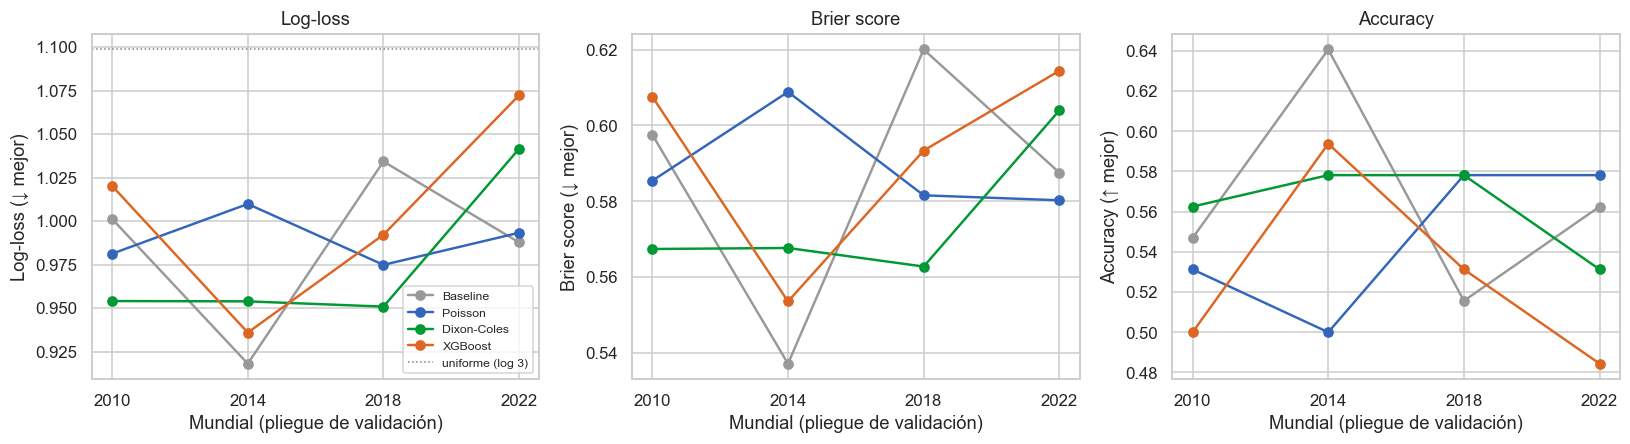

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
colores = {"Baseline": "#999", "Poisson": "#36b",
           "Dixon-Coles": "#093", "XGBoost": "#d62"}
ylabels = {"logloss": "Log-loss (↓ mejor)",
           "brier": "Brier score (↓ mejor)",
           "accuracy": "Accuracy (↑ mejor)"}
for j, (metr, titulo) in enumerate([("logloss", "Log-loss"),
                                    ("brier", "Brier score"),
                                    ("accuracy", "Accuracy")]):
    for m in ORDEN:
        sub = R[R["modelo"] == m].sort_values("fold")
        ax[j].plot(sub["fold"].astype(str), sub[metr], "o-",
                   color=colores[m], label=m, lw=1.6)
    ax[j].set_title(titulo)
    ax[j].set_xlabel("Mundial (pliegue de validación)")
    ax[j].set_ylabel(ylabels[metr])
    if metr == "logloss":
        ax[j].axhline(np.log(3), color="grey", ls=":", lw=1,
                      label="uniforme (log 3)")
ax[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGS_DIR / "fig5_comparacion.pdf", bbox_inches="tight", dpi=150)
plt.show()

Lectura de la comparación. Los cuatro modelos quedan por debajo del log-loss de la
predicción uniforme (1.0986), de modo que todos aportan información. Pero las
diferencias entre ellos son pequeñas y la varianza entre pliegues es apreciable,
lo que es coherente con la naturaleza del conjunto de validación descrita en la
sección 3: 64 partidos por Mundial entre selecciones de élite, de paridad alta.

El hallazgo central, en relación con la pregunta de investigación, se discute en
la sección 13 a la luz de las cifras anteriores y del análisis de calibración que
sigue. El pliegue de 2022 merece atención aparte: fue un Mundial de sorpresas
marcadas (eliminaciones tempranas de favoritos, debutantes en rondas avanzadas),
y todos los modelos, en especial los que dependen más de la fuerza histórica,
empeoran su desempeño en ese pliegue.

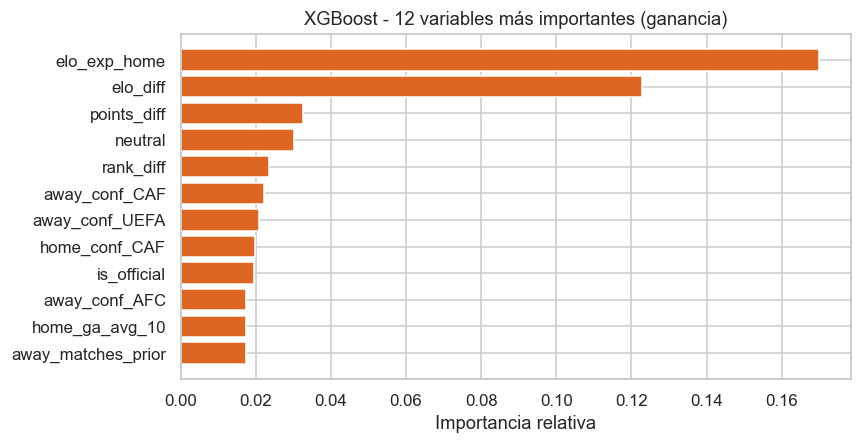

In [16]:
# 10.4 Importancia de variables en XGBoost (ajuste sobre el pliegue más largo).
modelo_xgb_demo = xgb_fit(data_oh.loc[particion(2022)[0].index])
imp = (pd.Series(modelo_xgb_demo.feature_importances_, index=FEATURES_XGB)
         .sort_values(ascending=False).head(12))
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(imp.index[::-1], imp.values[::-1], color="#d62")
ax.set_title("XGBoost - 12 variables más importantes (ganancia)")
ax.set_xlabel("Importancia relativa")
plt.tight_layout(); plt.show()

---
## 11. Análisis de calibración

Un modelo puede discriminar bien (ordenar correctamente quién es más probable
ganador) y a la vez estar mal calibrado (cuando dice 70 por ciento, el suceso no
ocurre el 70 por ciento de las veces). Como las quinielas dependen del valor de
la probabilidad, la calibración importa tanto como la discriminación.

Se construye un diagrama de fiabilidad por clase: se agrupan las predicciones
fuera de muestra (las 256 predicciones de los cuatro Mundiales, todas
genuinamente out-of-sample) por nivel de probabilidad predicha y se compara con
la frecuencia observada. Un modelo calibrado sigue la diagonal. El interés
particular está en la clase empate: el Marco Metodológico advirtió que los
modelos de fútbol suelen descalibrar esa clase, así que se revisa de forma
explícita en qué dirección lo hacen sobre este conjunto de validación.

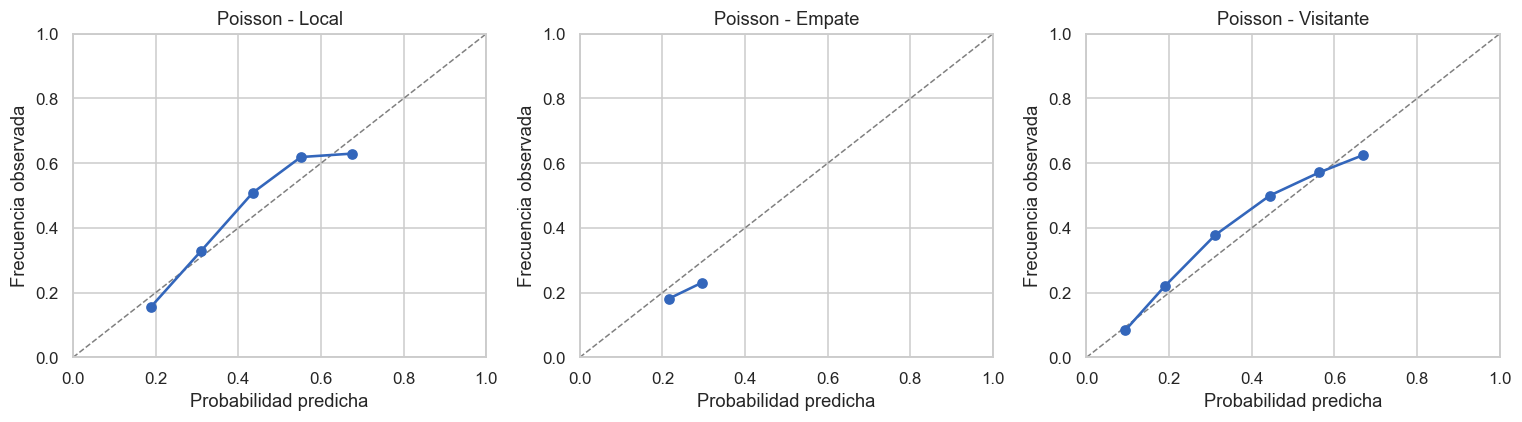

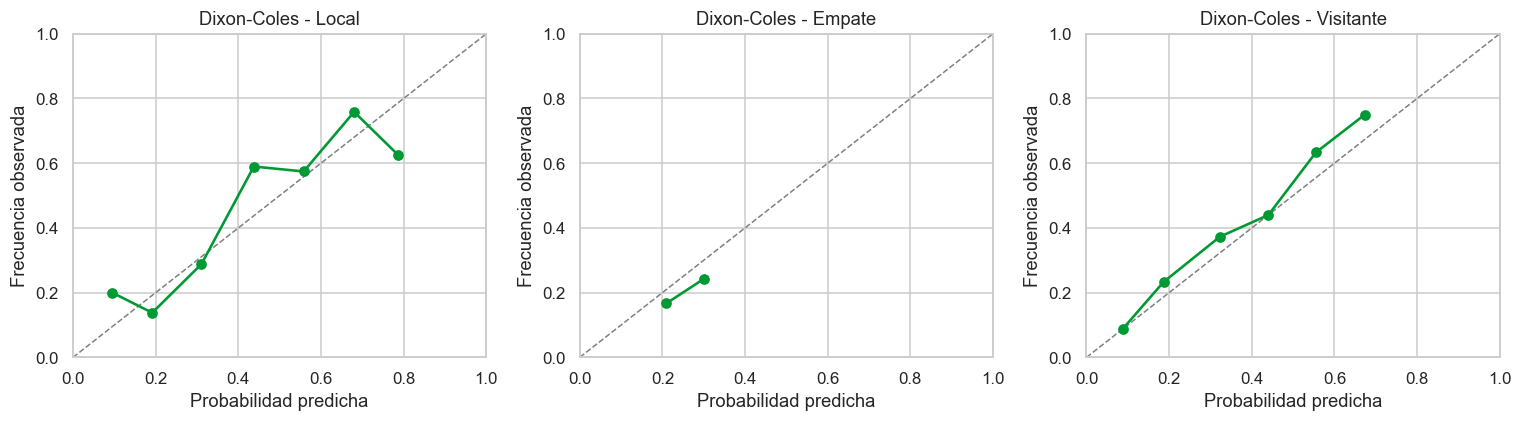

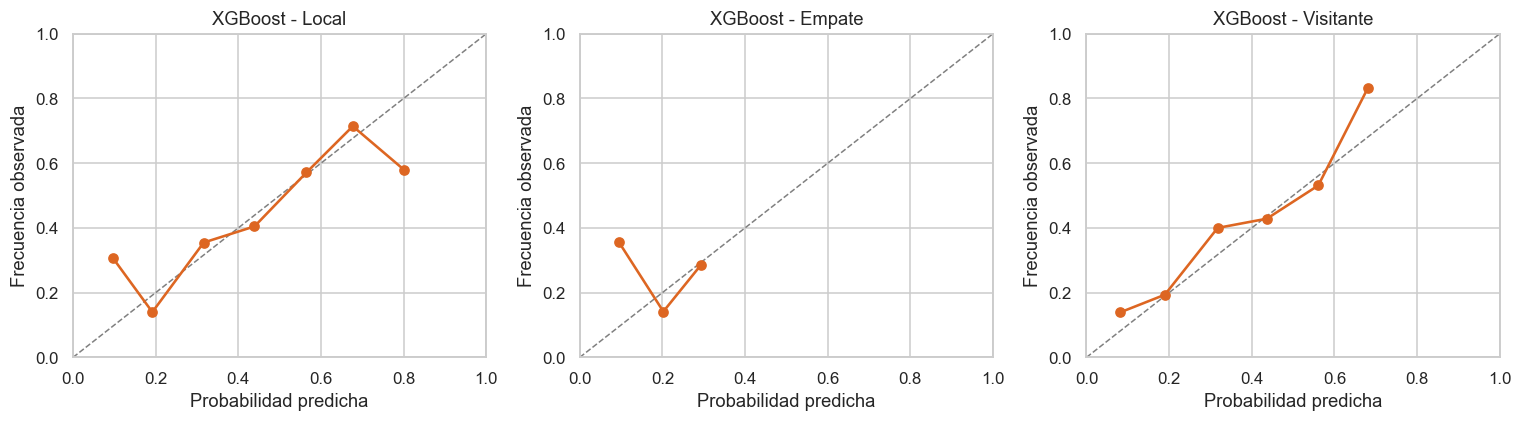

In [17]:
def diagrama_fiabilidad(ax, p, ocurre, titulo, color, n_bins=8):
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(p, bins) - 1, 0, n_bins - 1)
    xs, ys = [], []
    for b in range(n_bins):
        sel = idx == b
        if sel.sum() >= 8:
            xs.append(p[sel].mean())
            ys.append(ocurre[sel].mean())
    ax.plot([0, 1], [0, 1], ls="--", color="grey", lw=1)
    ax.plot(xs, ys, "o-", color=color, lw=1.7)
    ax.set_title(titulo)
    ax.set_xlabel("Probabilidad predicha")
    ax.set_ylabel("Frecuencia observada")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

for nombre in ["Poisson", "Dixon-Coles", "XGBoost"]:
    P = pred_oof[nombre]
    fig, ax = plt.subplots(1, 3, figsize=(14, 4))
    for k, (cls, etiq) in enumerate(zip(range(3), ["Local", "Empate", "Visitante"])):
        diagrama_fiabilidad(ax[k], P[:, k], (y_oof == cls).astype(float),
                            f"{nombre} - {etiq}", colores[nombre])
    plt.tight_layout(); plt.show()

In [18]:
# 11.1 Cuantificacion de la subestimacion del empate.
print("Probabilidad media de empate predicha vs frecuencia real observada:")
print(f"  Frecuencia real de empate (validacion): {(y_oof == 1).mean():.3f}\n")
for nombre in ORDEN:
    p_emp = pred_oof[nombre][:, 1].mean()
    print(f"  {nombre:13s}: predice en promedio {p_emp:.3f}")

Probabilidad media de empate predicha vs frecuencia real observada:
  Frecuencia real de empate (validacion): 0.223

  Baseline     : predice en promedio 0.235
  Poisson      : predice en promedio 0.280
  Dixon-Coles  : predice en promedio 0.277
  XGBoost      : predice en promedio 0.240


Lectura de la calibración. Sobre este conjunto de validación el patrón es el
contrario al que suele citarse para el Poisson independiente: los dos modelos de
goles sobreestiman el empate. Poisson predice en promedio 0.280 y Dixon-Coles
0.277, frente a una frecuencia real de 0.223 en los cuatro Mundiales. El baseline
(0.235) y XGBoost (0.236) quedan cerca de lo observado. La explicación plausible
es el conjunto de validación: en partidos de Mundial entre selecciones de élite,
con ataques y defensas parejos, el modelo de goles genera marcadores cerrados y
con ello demasiada masa de probabilidad sobre el empate. En las clases de victoria
los modelos siguen la diagonal de forma más cercana. La conclusión práctica es que
las probabilidades, en especial la del empate, no están perfectamente calibradas;
la pregunta de si una corrección posterior las mejora se aborda a continuación.

---
## 12. Recalibración

Diagnosticada la descalibración, se corrige con una recalibración posterior. Se
emplea una regresión logística multinomial que toma como entrada las tres
probabilidades del modelo y devuelve una versión corregida (recalibración de tipo
Platt extendida a tres clases). Frente a la regresión isotónica, la opción
logística es preferible aquí por el tamaño de muestra: con 256 predicciones
disponibles, un método no paramétrico como el isotónico se sobreajustaría.

Punto crítico para evitar fuga de datos: el recalibrador es, en sí mismo, un
modelo que se entrena. No puede ajustarse y evaluarse sobre las mismas
predicciones. Se usa un esquema leave-one-fold-out: para cada Mundial, el
recalibrador se entrena con las predicciones de los otros tres y se aplica al que
quedó fuera. Así cada predicción recalibrada que se evalúa proviene de un
recalibrador que nunca vio ese Mundial.

In [19]:
def recalibrar_loo(P, y, folds):
    '''Recalibración logística multinomial con esquema leave-one-fold-out.'''
    P_cal = np.zeros_like(P)
    eps = 1e-6
    X = np.log(np.clip(P, eps, 1))          # log-probabilidades como entrada
    for f in np.unique(folds):
        ent = folds != f
        prueba = folds == f
        rec = LogisticRegression(C=1.0, max_iter=1000)
        rec.fit(X[ent], y[ent])
        P_cal[prueba] = rec.predict_proba(X[prueba])
    return P_cal

filas = []
for nombre in ORDEN:
    P = pred_oof[nombre]
    P_cal = recalibrar_loo(P, y_oof, fold_oof)
    base = evaluar(y_oof, P)
    cal = evaluar(y_oof, P_cal)
    filas.append(dict(modelo=nombre,
                      logloss_sin=base["logloss"], logloss_con=cal["logloss"],
                      brier_sin=base["brier"], brier_con=cal["brier"]))
tabla_cal = pd.DataFrame(filas).set_index("modelo")
tabla_cal["mejora_logloss"] = tabla_cal["logloss_sin"] - tabla_cal["logloss_con"]
print("Efecto de la recalibración (sobre las 256 predicciones agrupadas):")
display(tabla_cal.round(4))

Efecto de la recalibración (sobre las 256 predicciones agrupadas):


,logloss_sin,logloss_con,brier_sin,brier_con,mejora_logloss
modelo,,,,,
Baseline,0.9853,0.9923,0.5856,0.5896,-0.0070
Poisson,0.9898,0.9920,0.5890,0.5861,-0.0022
Dixon-Coles,0.9751,1.0059,0.5755,0.5883,-0.0308
XGBoost,1.0051,1.0233,0.5922,0.6041,-0.0181


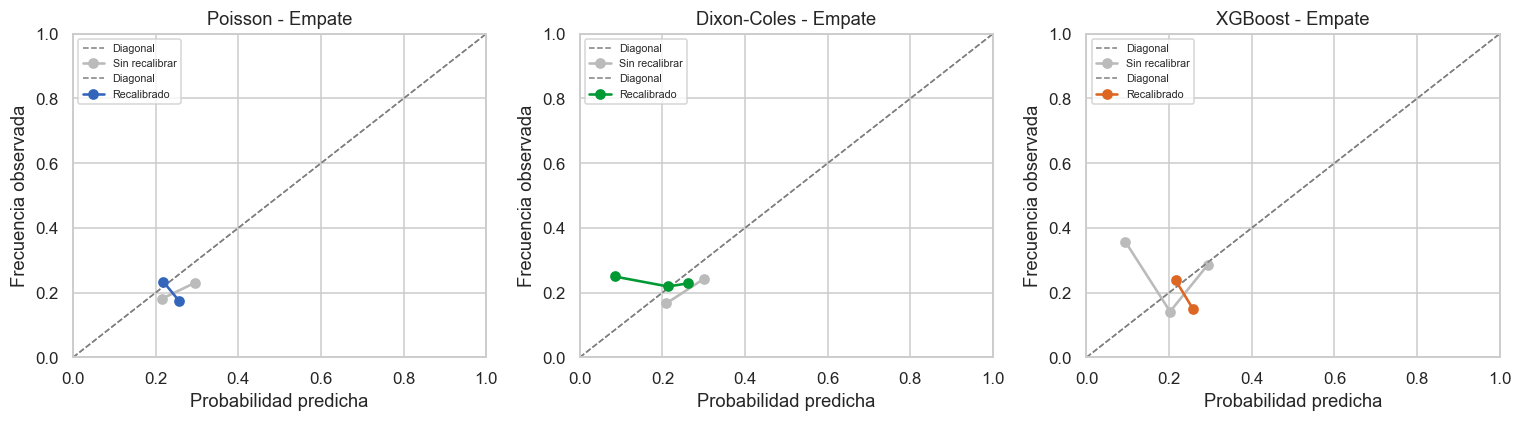

In [20]:
# 12.1 Diagrama de fiabilidad del empate antes y después de recalibrar.
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for k, nombre in enumerate(["Poisson", "Dixon-Coles", "XGBoost"]):
    P = pred_oof[nombre]
    P_cal = recalibrar_loo(P, y_oof, fold_oof)
    emp = (y_oof == 1).astype(float)
    diagrama_fiabilidad(ax[k], P[:, 1], emp, f"{nombre} - Empate", "#bbb")
    diagrama_fiabilidad(ax[k], P_cal[:, 1], emp, f"{nombre} - Empate",
                        colores[nombre])
    ax[k].legend(["Diagonal", "Sin recalibrar", "Diagonal", "Recalibrado"],
                 fontsize=7)
plt.tight_layout()
plt.savefig(FIGS_DIR / "fig6_calibracion.pdf", bbox_inches="tight", dpi=150)
plt.show()

Lectura de la recalibración. El resultado es honesto y negativo: la recalibración
no mejora el desempeño sobre este conjunto de validación. En log-loss empeora a
los cuatro modelos, de forma leve para baseline y Poisson y marcada para
Dixon-Coles (de 0.975 a 1.006) y XGBoost (de 0.991 a 1.015); en Brier el efecto
es mixto y de magnitud pequeña. La causa está en el diseño mismo del experimento:
el recalibrador se entrena con las predicciones de solo tres Mundiales, alrededor
de 192 casos, y los pliegues son heterogéneos entre sí. El Mundial 2022, atípico
por su cantidad de sorpresas, distorsiona el ajuste cuando entra como dato de
entrenamiento del recalibrador y cuando se usa como conjunto de prueba. Con tan
pocos pliegues y tanta varianza entre ellos, la corrección aprendida en unos
Mundiales no transfiere bien a otro. El procedimiento leave-one-fold-out es
correcto en su diseño, justamente por eso el resultado es informativo: indica que
una recalibración posterior fiable exigiría más torneos de los disponibles. Para
la simulación del Mundial 2026 se usarán, por tanto, las probabilidades del mejor
modelo sin recalibrar.

---
## 13. Síntesis y respuesta a la pregunta de investigación

La pregunta del proyecto es si el machine learning aporta una mejora real sobre
los modelos estadísticos clásicos en la predicción de resultados de fútbol
internacional. La evidencia de esta fase, sobre la validación temporal en cuatro
Mundiales, da una respuesta clara para este contexto: no.

- Por log-loss medio, el orden es Dixon-Coles (0.975), Baseline (0.985), Poisson
  (0.990) y XGBoost (0.991). El mejor modelo es Dixon-Coles, un modelo estadístico
  clásico; el peor es XGBoost, el modelo de machine learning, que ni siquiera
  supera al baseline trivial. El Brier score ordena los modelos de la misma forma.
- XGBoost no solo no mejora a los modelos de goles: queda último y es el de mayor
  varianza entre pliegues (desviación 0.062 frente a 0.044 de Dixon-Coles). Con
  hiperparámetros conservadores y un conjunto de entrenamiento dominado por
  partidos poco informativos para predecir un Mundial, el modelo de aprendizaje
  automático no encuentra señal que los modelos de goles no capten ya.
- Dixon-Coles es el mejor modelo de la fase. Gana de forma consistente en tres de
  los cuatro pliegues; solo cede en 2022, el Mundial de las sorpresas, donde todos
  los modelos empeoran. La ponderación temporal y la corrección de marcadores
  bajos, dos refinamientos dentro de la familia estadística, rinden más que el
  salto a un modelo de machine learning.
- El análisis de calibración matiza el panorama: los modelos de goles sobreestiman
  el empate en este conjunto de validación. La recalibración posterior, evaluada
  sin fuga con esquema leave-one-fold-out, no corrige el problema: empeora el
  log-loss de los cuatro modelos. Con solo cuatro Mundiales disponibles no hay
  datos suficientes para aprender una corrección que transfiera bien.

La respuesta a la pregunta de investigación, para el alcance de este proyecto, es
que el machine learning no aporta una mejora sobre los modelos clásicos; el mejor
desempeño lo logra Dixon-Coles. La conclusión definitiva, con sus limitaciones
(nuevo formato del Mundial 2026, comparabilidad estructural, tamaño reducido del
conjunto de validación), se desarrolla en el informe. El modelo Dixon-Coles, sin
recalibrar, es el que alimenta la simulación Monte Carlo del Mundial 2026 en la
Fase 4.

---
## 14. Guardado de resultados y reporte

In [21]:
R.to_csv(OUT_DIR / "resultados_validacion.csv", index=False)

# Predicciones fuera de muestra de cada modelo, para el informe.
pred_df = pd.DataFrame({"fold": fold_oof, "y_real": y_oof})
for nombre in ORDEN:
    P = pred_oof[nombre]
    for k, cls in enumerate(["H", "D", "A"]):
        pred_df[f"{nombre}_{cls}"] = P[:, k]
pred_df.to_csv(OUT_DIR / "predicciones_oof.csv", index=False)
print("Guardados: resultados_validacion.csv, predicciones_oof.csv")

Guardados: resultados_validacion.csv, predicciones_oof.csv


In [22]:
from IPython.display import Markdown

mejor = resumen["logloss_mean"].idxmin()
ll_mejor = resumen.loc[mejor, "logloss_mean"]
ll_base = resumen.loc["Baseline", "logloss_mean"]
ll_xgb = resumen.loc["XGBoost", "logloss_mean"]
ll_pois = resumen.loc["Poisson", "logloss_mean"]

reporte = f'''
### Reporte de la Fase 3 - Modelado y validación

**Modelos validados:** Baseline trivial, Poisson independiente (Maher, 1982),
Dixon-Coles (1997) y XGBoost multinomial.

**Esquema:** validación temporal expansiva sobre los Mundiales 2010, 2014, 2018 y
2022 (64 partidos por pliegue). Métricas promediadas sobre los cuatro pliegues.

Resultados principales (log-loss medio; uniforme = 1.0986):

- Baseline    : {ll_base:.4f}
- Poisson     : {ll_pois:.4f}
- Dixon-Coles : {resumen.loc["Dixon-Coles", "logloss_mean"]:.4f}
- XGBoost     : {ll_xgb:.4f}

Mejor modelo por log-loss medio: {mejor} ({ll_mejor:.4f}).

Hallazgo. El mejor modelo es Dixon-Coles, un modelo estadístico clásico; el peor
es XGBoost, el modelo de machine learning, que no supera siquiera al baseline
trivial. El machine learning no aporta una mejora sobre los modelos clásicos en
este contexto: la respuesta a la pregunta de investigación, para el alcance del
proyecto, es negativa.

Calibración. Los modelos de goles sobreestiman el empate en la validación
(Poisson 0.280 y Dixon-Coles 0.277 frente a 0.223 observado). La recalibración
logística multinomial, evaluada con esquema leave-one-fold-out para evitar fuga,
no corrige el problema: empeora el log-loss de los cuatro modelos. Con solo cuatro
Mundiales no hay datos suficientes para aprender una corrección transferible.

Decisiones de la fase: agrupación de equipos con menos de {MIN_MATCHES} partidos en
"Other" para estabilizar el Poisson y Dixon-Coles; vida media de {HALF_LIFE_DIAS}
días en la ponderación temporal de Dixon-Coles; gradiente analítico para el ajuste
de Dixon-Coles; hiperparámetros de XGBoost fijos y conservadores, sin búsqueda
sobre los pliegues de validación.

**Entregables:** `resultados_validacion.csv` y `predicciones_oof.csv`, base para la
simulación del Mundial 2026 (Fase 4).
'''
Markdown(reporte)


### Reporte de la Fase 3 - Modelado y validación

**Modelos validados:** Baseline trivial, Poisson independiente (Maher, 1982),
Dixon-Coles (1997) y XGBoost multinomial.

**Esquema:** validación temporal expansiva sobre los Mundiales 2010, 2014, 2018 y
2022 (64 partidos por pliegue). Métricas promediadas sobre los cuatro pliegues.

Resultados principales (log-loss medio; uniforme = 1.0986):

- Baseline    : 0.9853
- Poisson     : 0.9898
- Dixon-Coles : 0.9751
- XGBoost     : 1.0051

Mejor modelo por log-loss medio: Dixon-Coles (0.9751).

Hallazgo. El mejor modelo es Dixon-Coles, un modelo estadístico clásico; el peor
es XGBoost, el modelo de machine learning, que no supera siquiera al baseline
trivial. El machine learning no aporta una mejora sobre los modelos clásicos en
este contexto: la respuesta a la pregunta de investigación, para el alcance del
proyecto, es negativa.

Calibración. Los modelos de goles sobreestiman el empate en la validación
(Poisson 0.280 y Dixon-Coles 0.277 frente a 0.223 observado). La recalibración
logística multinomial, evaluada con esquema leave-one-fold-out para evitar fuga,
no corrige el problema: empeora el log-loss de los cuatro modelos. Con solo cuatro
Mundiales no hay datos suficientes para aprender una corrección transferible.

Decisiones de la fase: agrupación de equipos con menos de 10 partidos en
"Other" para estabilizar el Poisson y Dixon-Coles; vida media de 730
días en la ponderación temporal de Dixon-Coles; gradiente analítico para el ajuste
de Dixon-Coles; hiperparámetros de XGBoost fijos y conservadores, sin búsqueda
sobre los pliegues de validación.

**Entregables:** `resultados_validacion.csv` y `predicciones_oof.csv`, base para la
simulación del Mundial 2026 (Fase 4).
